# Scalar convergence regions — Figure 4.2

## Imports and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import lambertw
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply

max_order = 100
x0_values = np.linspace(0.0, 1.0, 501)
time_points = 2001

## Model and Simulation Functions

For the positive scalar system

$$
\dot{x}=\frac{x}{1+x^2},
$$

the top panels of Figure 4.2 display

$$
E^+(x_0,N,T^*)=
\log_{10}\!\left(
\min\left\{
\max\left\{
\sup_{0\leq t\leq T^*}\left|y_{1,N}^+(t)-x^+(t)\right|,
10^{-15}
\right\},10^5
\right\}
\right),
$$

for $T^*=0.01$ and $T^*=1$. The bottom panels display

$$
E^+(x_0,N)(t)=
\log_{10}\!\left(
\min\left\{
\max\left\{\left|y_{1,N}^+(t)-x^+(t)\right|,10^{-15}\right\},10^5
\right\}
\right),
$$

for $x_0=0.3$ and $x_0=0.5$.

In [2]:
def exact_solution(times, initial):
    argument = initial**2 * np.exp(initial**2 + 2.0 * times)
    return np.sqrt(lambertw(argument).real)


def carleman_matrix(order):
    rows = []
    columns = []
    values = []

    for k in range(1, order + 1):
        for ell in range(k, order + 1, 2):
            rows.append(k - 1)
            columns.append(ell - 1)
            values.append(k * (-1) ** ((ell - k) // 2))

    return csr_matrix(
        (values, (rows, columns)),
        shape=(order, order),
        dtype=float,
    )


def first_row_coefficients(matrix, times):
    basis = np.zeros(matrix.shape[0])
    basis[0] = 1.0

    return expm_multiply(
        matrix.T,
        basis,
        start=float(times[0]),
        stop=float(times[-1]),
        num=times.size,
        endpoint=True,
        traceA=float(matrix.diagonal().sum()),
    )


def maximal_error_map(final_time, matrix):
    times = np.linspace(0.0, final_time, time_points)
    coefficients = first_row_coefficients(matrix, times)
    exact = exact_solution(times[:, None], x0_values[None, :])
    powers = x0_values[None, :] ** np.arange(1, max_order + 1)[:, None]

    approximation = np.zeros_like(exact)
    errors = np.empty((max_order, x0_values.size))

    for order_index in range(max_order):
        approximation += coefficients[:, order_index, None] * powers[order_index]
        errors[order_index] = np.max(np.abs(approximation - exact), axis=0)

    errors[:, 0] = 0.0
    return np.log10(np.clip(errors, 1e-15, 1e5)), errors


def pointwise_error_map(initial, matrix):
    times = np.linspace(0.0, 1.0, time_points)
    coefficients = first_row_coefficients(matrix, times)
    exact = exact_solution(times, initial)

    approximation = np.zeros(times.size)
    errors = np.empty((max_order, times.size))

    for order_index in range(max_order):
        approximation += coefficients[:, order_index] * initial ** (order_index + 1)
        errors[order_index] = np.abs(approximation - exact)

    return times, np.log10(np.clip(errors, 1e-15, 1e5)), errors

## Simulation

In [3]:
matrix = carleman_matrix(max_order)
top_left, errors_001 = maximal_error_map(0.01, matrix)
top_right, errors_1 = maximal_error_map(1.0, matrix)
times, bottom_left, pointwise_03 = pointwise_error_map(0.3, matrix)
_, bottom_right, pointwise_05 = pointwise_error_map(0.5, matrix)

check_initial = 0.3
check_times = np.linspace(0.0, 1.0, 401)
check_order = 19
check_matrix = carleman_matrix(check_order)
check_lifted = check_initial ** np.arange(1, check_order + 1)

direct = expm_multiply(
    check_matrix,
    check_lifted,
    start=0.0,
    stop=1.0,
    num=check_times.size,
    endpoint=True,
    traceA=float(check_matrix.diagonal().sum()),
)[:, 0]

nested = first_row_coefficients(matrix, check_times)[:, :check_order] @ check_lifted
numerical = solve_ivp(
    lambda _, state: state / (1.0 + state**2),
    (0.0, 1.0),
    [check_initial],
    t_eval=check_times,
    rtol=1e-12,
    atol=1e-14,
).y[0]

nested_check = np.max(np.abs(direct - nested))
exact_check = np.max(
    np.abs(numerical - exact_solution(check_times, check_initial))
)

## Results

Nested finite-section check: 2.993e-14
Exact solution check:       4.084e-12
Pointwise error, x0=0.3, N=100, t=1: 1.386184e+08
Pointwise error, x0=0.5, N=100, t=1: 1.675573e+30


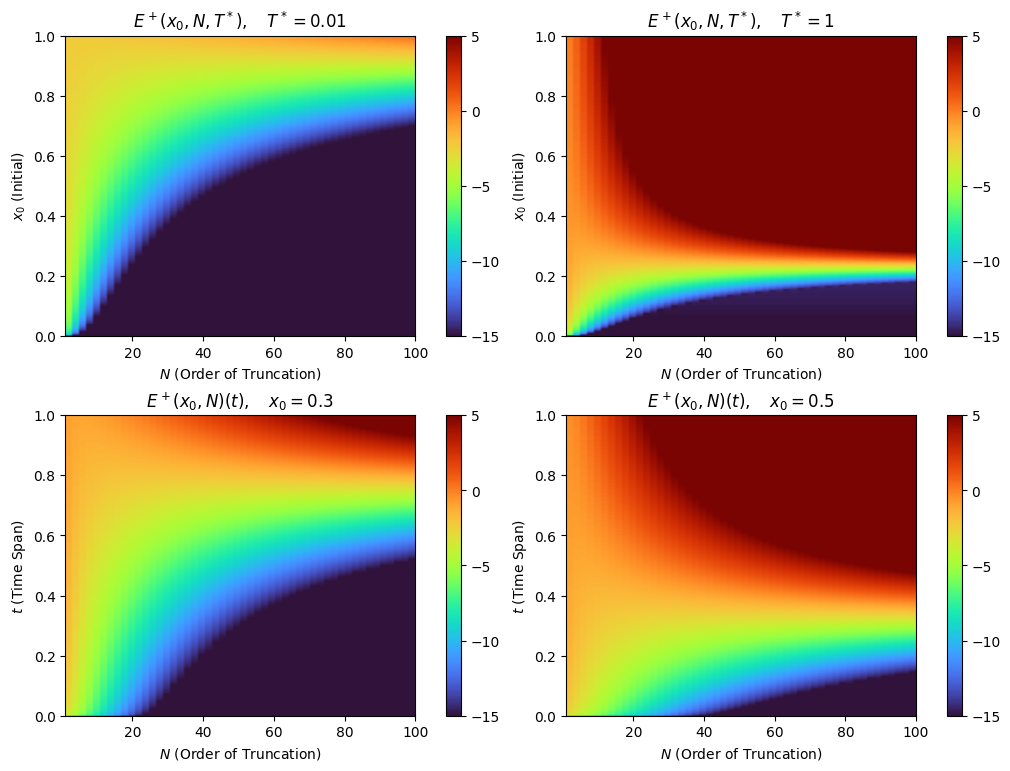

: 

In [ ]:
figure, axes = plt.subplots(2, 2, figsize=(10.0, 7.6), constrained_layout=True)
top_extent = [1, max_order, 0.0, 1.0]
bottom_extent = [1, max_order, 0.0, 1.0]

panels = [
    (axes[0, 0], top_left, top_extent, r"$E^+(x_0,N,T^*),\quad T^*=0.01$", r"$x_0$ (Initial)"),
    (axes[0, 1], top_right, top_extent, r"$E^+(x_0,N,T^*),\quad T^*=1$", r"$x_0$ (Initial)"),
    (axes[1, 0], bottom_left, bottom_extent, r"$E^+(x_0,N)(t),\quad x_0=0.3$", r"$t$ (Time Span)"),
    (axes[1, 1], bottom_right, bottom_extent, r"$E^+(x_0,N)(t),\quad x_0=0.5$", r"$t$ (Time Span)"),
]

for axis, values, extent, title, ylabel in panels:
    image = axis.imshow(
        values.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="turbo",
        vmin=-15,
        vmax=5,
    )
    axis.set_title(title)
    axis.set_xlabel(r"$N$ (Order of Truncation)")
    axis.set_ylabel(ylabel)
    figure.colorbar(image, ax=axis, ticks=[-15, -10, -5, 0, 5])

print(f"Nested finite-section check: {nested_check:.3e}")
print(f"Exact solution check:       {exact_check:.3e}")
print(f"Pointwise error, x0=0.3, N=100, t=1: {pointwise_03[-1, -1]:.6e}")
print(f"Pointwise error, x0=0.5, N=100, t=1: {pointwise_05[-1, -1]:.6e}")